In [17]:
import os
import cv2
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

ORIGINAL_DATA_DIR = r'C:\Users\dinht\Documents\DeepLearning\TapTrain'       
TEST_DIR = r'C:\Users\dinht\Documents\DeepLearning\TapTest' 
CROPPED_DATA_DIR = 'Processed_Train'

BATCH_SIZE = 32
NUM_EPOCHS = 40       
LEARNING_RATE = 0.001  

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Thiết bị: {device}")

🚀 Thiết bị: cuda


In [19]:

def imread_unicode(path):
    try:
        stream = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(stream, cv2.IMREAD_COLOR)
        return img
    except Exception:
        return None

def imwrite_unicode(path, img):
    try:
        ext = os.path.splitext(path)[1]
        is_success, buffer = cv2.imencode(ext, img)
        if is_success:
            buffer.tofile(path)
            return True
    except Exception:
        pass
    return False

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def extract_face(image_path, save_path=None):
    try:
        img = imread_unicode(image_path)
        if img is None: return None
        
        h_orig, w_orig = img.shape[:2]
        

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=3, minSize=(30, 30))
        
        face_img = None
        
        if len(faces) > 0:

            best_face = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)[0]
            x, y, w, h = best_face

            margin = 0.15
            x = max(0, int(x - w * margin))
            y = max(0, int(y - h * margin))
            w = int(w * (1 + 2*margin))
            h = int(h * (1 + 2*margin))
            
            face_img = img[y:y+h, x:x+w]
        
        else:

            min_side = min(h_orig, w_orig)
            center_x, center_y = w_orig // 2, h_orig // 2
            half_side = min_side // 2
            
            x_start = max(0, center_x - half_side)
            y_start = max(0, center_y - half_side)
            x_end = min(w_orig, center_x + half_side)
            y_end = min(h_orig, center_y + half_side)
            
            face_img = img[y_start:y_end, x_start:x_end]


        if face_img is None or face_img.size == 0: return None
        
        # Resize chuẩn 224x224
        face_img = cv2.resize(face_img, (224, 224))
        
        if save_path:
            imwrite_unicode(save_path, face_img)
            
        return Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
        
    except Exception as e:

        return None

In [20]:
def preprocess_data():
    print("\n--- ✂️ BẮT ĐẦU CẮT ẢNH ---")
    if not os.path.exists(ORIGINAL_DATA_DIR):
        print(f"❌ Không tìm thấy thư mục: {ORIGINAL_DATA_DIR}")
        return

    count = 0
    for class_name in os.listdir(ORIGINAL_DATA_DIR):
        class_path = os.path.join(ORIGINAL_DATA_DIR, class_name)
        if not os.path.isdir(class_path): continue
        
        save_path = os.path.join(CROPPED_DATA_DIR, class_name)
        os.makedirs(save_path, exist_ok=True)
        
        files = os.listdir(class_path)
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.jfif')):
                full_path = os.path.join(class_path, file)
                save_file_path = os.path.join(save_path, f"{os.path.splitext(file)[0]}.jpg")
                
                if extract_face(full_path, save_path=save_file_path):
                    count += 1
        print(f"✅ Đã xử lý class: {class_name}")
    print(f"🎉 Hoàn tất! Đã cắt được {count} ảnh.")

# Chỉ chạy nếu chưa có dữ liệu
if not os.path.exists(CROPPED_DATA_DIR) or len(os.listdir(CROPPED_DATA_DIR)) == 0:
    preprocess_data()
else:
    print("✅ Dữ liệu đã được xử lý trước đó.")


--- ✂️ BẮT ĐẦU CẮT ẢNH ---
✅ Đã xử lý class: Antony
✅ Đã xử lý class: Brad Pitt
✅ Đã xử lý class: charles_leclerc
✅ Đã xử lý class: Conor McGregor
✅ Đã xử lý class: David Beckham
✅ Đã xử lý class: Erling Haaland
✅ Đã xử lý class: faker
✅ Đã xử lý class: Jeff Bezo
✅ Đã xử lý class: Jeffray
✅ Đã xử lý class: Joji
✅ Đã xử lý class: Khabib
✅ Đã xử lý class: Leonardo DiCaprio
✅ Đã xử lý class: Levi
✅ Đã xử lý class: Messi
✅ Đã xử lý class: Mixigaming
✅ Đã xử lý class: Park Hang-seo
✅ Đã xử lý class: Robert_Downey_Junior
✅ Đã xử lý class: Ronaldo
✅ Đã xử lý class: SonTungMTP
✅ Đã xử lý class: Taylor_Swift
✅ Đã xử lý class: thayongnoi
✅ Đã xử lý class: Tobey_Maguire
✅ Đã xử lý class: Tom Hanks
✅ Đã xử lý class: Tom_Cruise
✅ Đã xử lý class: Trây Trín Pảy
✅ Đã xử lý class: Will_Smith
✅ Đã xử lý class: Zhao Lusi
✅ Đã xử lý class: Đại tướng Võ Nguyên Giáp
🎉 Hoàn tất! Đã cắt được 448 ảnh.


In [21]:
import os
import random
import shutil
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split

# --- CẤU HÌNH ĐƯỜNG DẪN ---
# Thư mục chứa ảnh đã cắt mặt (Input)
SOURCE_DATA_DIR = 'Processed_Train'  # hoặc 'Processed_Data_ResNet' tùy biến bạn đặt trước đó

# Thư mục đầu ra cuối cùng (Output)
FINAL_DATA_DIR = 'Final_Dataset'
TRAIN_DIR = os.path.join(FINAL_DATA_DIR, 'Train')
VAL_DIR = os.path.join(FINAL_DATA_DIR, 'Val')

def prepare_and_augment_data(target_train_count=100, val_ratio=0.3):
    print(f"\n--- 🔄 BẮT ĐẦU CHIA TẬP DỮ LIỆU VÀ NHÂN BẢN ---")
    
    # 1. Làm sạch thư mục đích nếu đã tồn tại (để làm mới)
    if os.path.exists(FINAL_DATA_DIR):
        shutil.rmtree(FINAL_DATA_DIR)
    
    # Kiểm tra nguồn
    if not os.path.exists(SOURCE_DATA_DIR):
        print("❌ Lỗi: Không tìm thấy thư mục dữ liệu nguồn!")
        return

    # Các phép biến đổi (Chỉ dùng cho Train)
    aug_transforms = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
        transforms.RandomPerspective(distortion_scale=0.2, p=0.5) 
    ])

    classes = [d for d in os.listdir(SOURCE_DATA_DIR) if os.path.isdir(os.path.join(SOURCE_DATA_DIR, d))]
    total_aug_created = 0

    for cls in classes:
        src_cls_path = os.path.join(SOURCE_DATA_DIR, cls)
        
        # Tạo thư mục đích cho lớp này
        dest_train_path = os.path.join(TRAIN_DIR, cls)
        dest_val_path = os.path.join(VAL_DIR, cls)
        os.makedirs(dest_train_path, exist_ok=True)
        os.makedirs(dest_val_path, exist_ok=True)
        
        # Lấy danh sách ảnh gốc
        images = [f for f in os.listdir(src_cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        if len(images) == 0: continue

        # --- BƯỚC 1: CHIA TRAIN / VAL ---
        # Nếu ít ảnh quá thì mặc định cho vào Train hết
        if len(images) > 1:
            train_files, val_files = train_test_split(images, test_size=val_ratio, random_state=42)
        else:
            train_files, val_files = images, []

        # Copy ảnh Val (Giữ nguyên gốc, KHÔNG Augment)
        for f in val_files:
            shutil.copy(os.path.join(src_cls_path, f), os.path.join(dest_val_path, f))

        # Copy ảnh Train gốc
        for f in train_files:
            shutil.copy(os.path.join(src_cls_path, f), os.path.join(dest_train_path, f))

        # --- BƯỚC 2: NHÂN BẢN TẬP TRAIN (AUGMENTATION) ---
        current_train_count = len(train_files)
        
        if current_train_count < target_train_count:
            needed = target_train_count - current_train_count
            print(f"🔹 {cls}: Có {current_train_count} train -> Tạo thêm {needed} ảnh...")
            
            for i in range(needed):
                # Chọn ngẫu nhiên 1 ảnh trong tập Train gốc để biến đổi
                original_img_name = random.choice(train_files)
                original_img_path = os.path.join(src_cls_path, original_img_name)
                
                try:
                    img = Image.open(original_img_path).convert('RGB')
                    # Áp dụng biến đổi
                    new_img = aug_transforms(img)
                    
                    # Lưu vào thư mục Train mới
                    new_name = f"aug_{i}_{original_img_name}"
                    new_img.save(os.path.join(dest_train_path, new_name))
                    total_aug_created += 1
                except Exception as e:
                    pass
        else:
            print(f"🔹 {cls}: Đã đủ {current_train_count} ảnh train (Bỏ qua nhân bản).")

    print(f"\n✅ HOÀN TẤT!")
    print(f"   - Tổng ảnh nhân bản thêm: {total_aug_created}")
    print(f"   - Dữ liệu cuối cùng nằm tại: {FINAL_DATA_DIR}")
    print(f"     + Train: {TRAIN_DIR}")
    print(f"     + Val:   {VAL_DIR}")

# --- CHẠY HÀM ---
# target_train_count=100: Đảm bảo mỗi lớp trong tập Train có ít nhất 100 ảnh
prepare_and_augment_data(target_train_count=100, val_ratio=0.2)


--- 🔄 BẮT ĐẦU CHIA TẬP DỮ LIỆU VÀ NHÂN BẢN ---
🔹 Antony: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Brad Pitt: Có 12 train -> Tạo thêm 88 ảnh...
🔹 charles_leclerc: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Conor McGregor: Có 12 train -> Tạo thêm 88 ảnh...
🔹 David Beckham: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Erling Haaland: Có 12 train -> Tạo thêm 88 ảnh...
🔹 faker: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Jeff Bezo: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Jeffray: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Joji: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Khabib: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Leonardo DiCaprio: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Levi: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Messi: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Mixigaming: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Park Hang-seo: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Robert_Downey_Junior: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Ronaldo: Có 12 train -> Tạo thêm 88 ảnh...
🔹 SonTungMTP: Có 12 train -> Tạo thêm 88 ảnh...
🔹 Taylor_Swift: Có 12 train -> Tạo thêm 88

In [22]:
def train_model_anti_overfit():
    print(f"🚀 Bắt đầu training với Train: {TRAIN_DIR} | Val: {VAL_DIR}")

    # --- 1. DATA LOADING ---
    
    train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.3), 
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    if not os.path.exists(TRAIN_DIR) or not os.path.exists(VAL_DIR):
        print(f"Lỗi: Không tìm thấy thư mục {TRAIN_DIR} hoặc {VAL_DIR}")
        return None, None

    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    class_names = train_dataset.classes
    print(f"✅ Đã load: Train ({len(train_dataset)} ảnh) | Val ({len(val_dataset)} ảnh)")

    # --- 2. MODEL SETUP ---
    
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # Freeze 50% lớp đầu
    for param in model.features[0:5].parameters():
        param.requires_grad = False
    for param in model.features[5:].parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.7), 
        nn.Linear(in_features, len(class_names))
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    lr_to_use = LEARNING_RATE if 'LEARNING_RATE' in globals() else 0.001
    optimizer = optim.Adam(model.parameters(), lr=lr_to_use, weight_decay=1e-3) 
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # --- 3. TRAINING LOOP ---
    for epoch in range(NUM_EPOCHS): 
        model.train()
        running_corrects = 0
        
        # Train Step
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
        train_acc = running_corrects.double() / len(train_dataset)

        # Val Step
        model.eval()
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
        val_acc = val_corrects.double() / len(val_dataset)

        curr_lr = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch+1:02d}/{NUM_EPOCHS} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {curr_lr:.6f}")
        
        scheduler.step(val_acc)
        
        if val_acc > best_acc:
            print(f"   -> ({val_acc:.4f} > {best_acc:.4f}). Đang lưu 'best_model.pth'...")
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_model.pth')

    print(f"\n Hoàn tất! Best Val Acc: {best_acc:.4f}")
    
    # Load lại trọng số tốt nhất trước khi return
    model.load_state_dict(best_model_wts)
    return model, class_names

# Chạy cell
trained_model, class_names = train_model_anti_overfit()

🚀 Bắt đầu training với Train: Final_Dataset\Train | Val: Final_Dataset\Val
✅ Đã load: Train (2800 ảnh) | Val (112 ảnh)
Ep 01/40 | Train: 0.7229 | Val: 0.8036 | LR: 0.001000
   -> (0.8036 > 0.0000). Đang lưu 'best_model.pth'...
Ep 02/40 | Train: 0.9904 | Val: 0.8839 | LR: 0.001000
   -> (0.8839 > 0.8036). Đang lưu 'best_model.pth'...
Ep 03/40 | Train: 0.9868 | Val: 0.8036 | LR: 0.001000
Ep 04/40 | Train: 0.9739 | Val: 0.8125 | LR: 0.001000
Ep 05/40 | Train: 0.9718 | Val: 0.7946 | LR: 0.001000
Ep 06/40 | Train: 0.9839 | Val: 0.8036 | LR: 0.001000
Ep 07/40 | Train: 0.9918 | Val: 0.8750 | LR: 0.000500
Ep 08/40 | Train: 0.9979 | Val: 0.8661 | LR: 0.000500
Ep 09/40 | Train: 0.9979 | Val: 0.8750 | LR: 0.000500
Ep 10/40 | Train: 0.9993 | Val: 0.8929 | LR: 0.000500
   -> (0.8929 > 0.8839). Đang lưu 'best_model.pth'...
Ep 11/40 | Train: 0.9996 | Val: 0.8839 | LR: 0.000500
Ep 12/40 | Train: 0.9982 | Val: 0.8750 | LR: 0.000500
Ep 13/40 | Train: 0.9989 | Val: 0.9196 | LR: 0.000500
   -> (0.9196 > 0

Đang tải lại Model và Danh sách lớp...


C:\Users\dinht\AppData\Local\Temp\ipykernel_11792\432802923.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_eval.load_state_dict(torch.load('best_model.pth', map_

🚀 Bắt đầu đánh giá trên 28 lớp nhân vật...

🌟 ĐỘ CHÍNH XÁC TỔNG THỂ (ACCURACY): 86.49%
------------------------------------------------------------
 CHI TIẾT TỪNG LỚP:
                          precision    recall  f1-score   support

                  Antony       1.00      1.00      1.00         4
               Brad Pitt       0.60      1.00      0.75         3
          Conor McGregor       1.00      1.00      1.00         4
           David Beckham       1.00      1.00      1.00         4
          Erling Haaland       1.00      1.00      1.00         4
               Jeff Bezo       0.57      1.00      0.73         4
                 Jeffray       1.00      1.00      1.00         4
                    Joji       0.00      0.00      0.00         4
                  Khabib       1.00      1.00      1.00         4
       Leonardo DiCaprio       1.00      1.00      1.00         4
                    Levi       0.67      1.00      0.80         4
                   Messi       1.00    

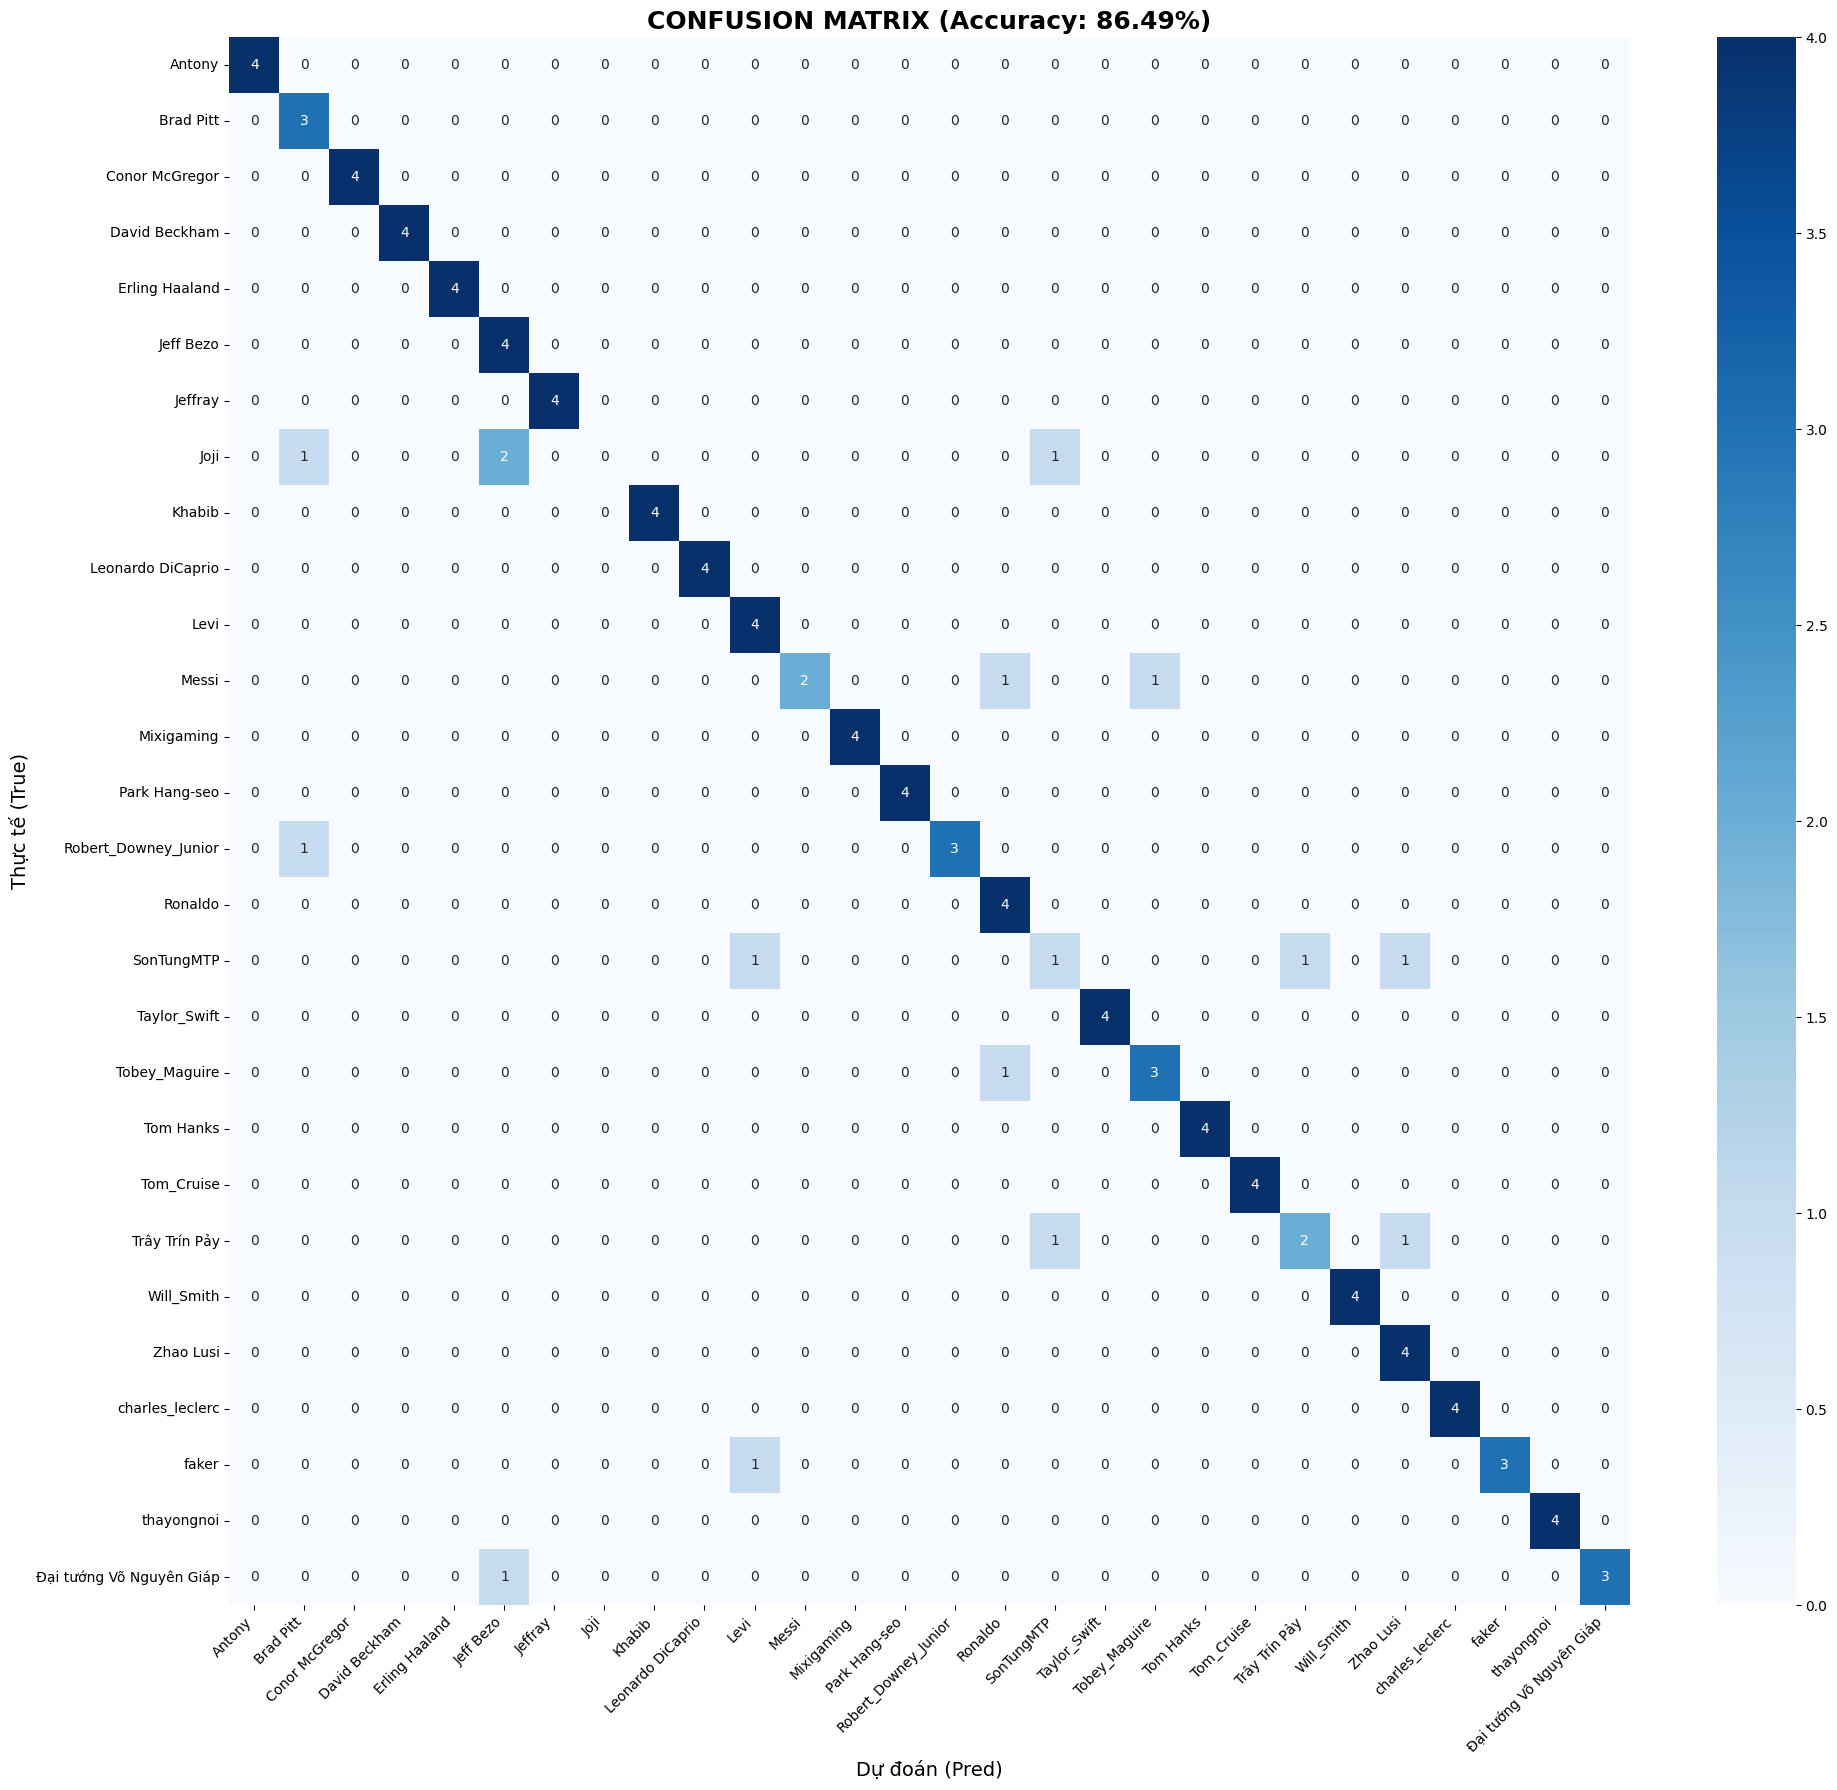

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("Đang tải lại Model và Danh sách lớp...")
if os.path.exists(CROPPED_DATA_DIR):
    dummy_ds = datasets.ImageFolder(CROPPED_DATA_DIR)
    class_names = dummy_ds.classes
else:
    print("Cảnh báo: Không tìm thấy folder Processed_Train để lấy tên class!")

model_eval = models.efficientnet_b0(weights=None)
in_features = model_eval.classifier[1].in_features
model_eval.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, len(class_names))
)


model_eval.load_state_dict(torch.load('best_model.pth', map_location=device))
model_eval.to(device)
model_eval.eval()

print(f"🚀 Bắt đầu đánh giá trên {len(class_names)} lớp nhân vật...")

y_true = []
y_pred = []

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

with torch.no_grad():
    for cls_idx, cls_name in enumerate(class_names):
        folder_path = os.path.join(TEST_DIR, cls_name)
        if not os.path.isdir(folder_path): continue
        
        for f in os.listdir(folder_path):
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):

                face = extract_face(os.path.join(folder_path, f))
                
                if face:

                    img_t = test_transform(face).unsqueeze(0).to(device)
                    outputs = model_eval(img_t)
                    _, predicted = torch.max(outputs, 1)
                    
                    y_true.append(cls_idx)
                    y_pred.append(predicted.item())


if len(y_true) > 0:

    acc = accuracy_score(y_true, y_pred) * 100
    print(f"\n🌟 ĐỘ CHÍNH XÁC TỔNG THỂ (ACCURACY): {acc:.2f}%")
    print("-" * 60)
    

    print(" CHI TIẾT TỪNG LỚP:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    print("Đang vẽ biểu đồ...")
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f'CONFUSION MATRIX (Accuracy: {acc:.2f}%)', fontsize=18, fontweight='bold')
    plt.ylabel('Thực tế (True)', fontsize=14)
    plt.xlabel('Dự đoán (Pred)', fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ảnh nào trong tập Test để đánh giá.")